In [19]:
import numpy as np
import matplotlib.pyplot as plt
from qopt_funcs import *

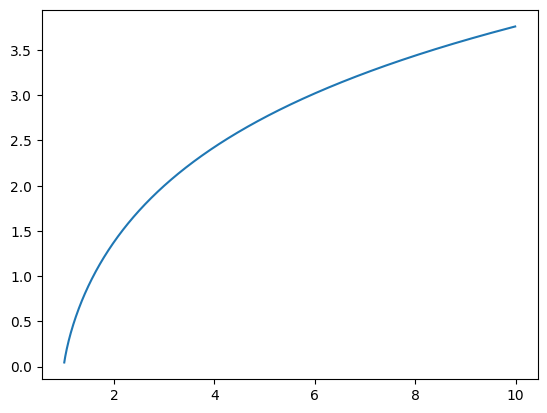

In [20]:
G = lambda X: np.array([g(x) for x in X])

X= np.arange(1.01, 10.0, 0.01)
plt.plot(X, G(X))

# Continuous-variable QKD key rates

In this notebook we are computing the secret key rates for CV-QKD protocols following the calculations in Table III (below) of Zhang et al.'s "_Continuous-variable quantum key distribution system: Past, present, and future_" (2024), __[APR version](https://pubs.aip.org/aip/apr/article/11/1/011318/3279669/Continuous-variable-quantum-key-distribution)__. 

The __[arXiv](https://arxiv.org/pdf/2310.04831)__ version does not have the table but it has an in-text explanation.

NOTE: the $G(x)$ in the table corresponds to the `g(x)` entropy function defined in `qopt_funcs`.

![alt text](zhang_table.png)

In [21]:
V = 5
T= np.linspace(0.5, 1., 10)
exc_noise = 0.1
chi = (1 - T)/T + exc_noise
a, b, c = V, T*(V + chi), np.sqrt(T*(V**2 - 1))
Delta = a**2 + b**2 - 2*c**2
D = a*b - c**2
A = (a + b*D + Delta)/(a + 1)
A_prime = (b + a*D + Delta)/(b + 1)
B = D*(b + D)/(a + 1)
B_prime = D*(a + D)/(b + 1)

## Eigenvalues of the covariance matrix

Reporting here the expressions of the eigenvalues of the cov. mtx and of the conditional cov. mtx, as written in Table III. 

All possible combinations of homo-/hetero-dyne measurement, squeezed/coherent states, direct/reverse reconciliation are considered. 

To avoid confusion, the ```lambdas``` are numbered according to Zhang's notation. 

In [22]:

lambdas = np.zeros((13, len(T)))    # leaving the 1st one empty to use indeces from 1 to 12
lambdas[0] = T    # to keep track of the transmittance values

# Alice and Bob's covariance matrix eigenvalues before measurement
lambdas[1] = np.sqrt(0.5*(Delta + np.sqrt(Delta**2 - 4*D**2)))
lambdas[2] = np.sqrt(0.5*(Delta - np.sqrt(Delta**2 - 4*D**2)))


# HOMODYNE measurement

## squeezed states
### direct reconciliation
lambdas[3] = np.sqrt(T**2*(V + chi)/(chi + 1/V))
### reverse reconciliation
lambdas[4] = np.sqrt(V*(V*chi + 1)/(chi + V))

## coherent states
### direct reconciliation
lambdas[5] = np.sqrt(0.5*(A + np.sqrt(A**2 - 4*B)))
lambdas[6] = np.sqrt(0.5*(A - np.sqrt(A**2 - 4*B)))
### reverse reconciliation
lambdas[7] = np.sqrt(V*(V*chi + 1)/(chi + V))


# HETERODYNE measurement

## squeezed states
### direct reconciliation
lambdas[8] = np.sqrt(T**2*(V + chi)/(chi + 1/V))
### reverse reconciliation
lambdas[9] = np.sqrt(0.5*(A_prime + np.sqrt(A_prime**2 - 4*B_prime)))
lambdas[10] = np.sqrt(0.5*(A_prime - np.sqrt(A_prime**2 - 4*B_prime)))

## coherent states
### direct reconciliation
lambdas[11] = T*(chi + 1)
### reverse reconciliation
lambdas[12] = (T*(V*chi + 1) + 1)/(T*(V + chi) + 1)

with np.printoptions(threshold=np.inf):
    print(lambdas)


[[0.5        0.55555556 0.61111111 0.66666667 0.72222222 0.77777778
  0.83333333 0.88888889 0.94444444 1.        ]
 [3.02454263 2.80971777 2.5963983  2.38484062 2.17535651 1.96832652
  1.76421642 1.56359661 1.36716408 1.27576507]
 [1.07454263 1.08749555 1.10195385 1.11817395 1.13646762 1.15721541
  1.18088309 1.20804105 1.23938631 1.17576507]
 [1.08308676 1.28664032 1.51257266 1.76383421 2.04418694 2.35849129
  2.71313677 3.11670832 3.58105751 4.12310563]
 [2.30821768 2.15893885 2.02010497 1.88982237 1.76652685 1.64888838
  1.53573779 1.4260059  1.31866696 1.21267813]
 [1.76142693 1.70448722 1.64652649 1.58753127 1.52754773 1.46675093
  1.40559913 1.34518727 1.28801436 1.23906076]
 [1.04874933 1.05363913 1.05822757 1.06237157 1.06583841 1.0682279
  1.06880618 1.06613509 1.05727953 1.03669109]
 [2.30821768 2.15893885 2.02010497 1.88982237 1.76652685 1.64888838
  1.53573779 1.4260059  1.31866696 1.21267813]
 [1.08308676 1.28664032 1.51257266 1.76383421 2.04418694 2.35849129
  2.71313677 

## Mutual information expressions

These do NOT depend on the direct/reverse reconciliation protocol.

In [ ]:
# i know it's a mess, i'm calling global variables inside the functions, as long as it works for now

def mutual_information_CV(states='squeezed', detection_mode='homodyne'):
    if states == 'squeezed' and detection_mode == 'homodyne':
        return 0.5*np.log2(V + chi)/(chi + 1/V)
    elif states == 'coherent' and detection_mode == 'homodyne':
        return 0.5*np.log2((V + chi)/(chi + 1))
    
    elif states == 'squeezed' and detection_mode == 'heterodyne':
        return 0.5*np.log2(T*(V + chi) + 1)/(T*(chi + 1/V) + 1)
    elif states == 'coherent' and detection_mode == 'heterodyne':
        return 0.5*np.log2(T*(V + chi) + 1)/(T*(chi + 1) + 1)
    
    else:
        raise ValueError("Invalid \'states\' or \'detection_mode\' argument")


def holevo_bound_CV(states='squeezed', detection_mode='homodyne', reconciliation='direct'):
    if states == 'squeezed' and detection_mode == 'homodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[3]) 
    elif states == 'squeezed' and detection_mode == 'homodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[4])
    
    elif states == 'coherent' and detection_mode == 'homodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[5]) - g(lambdas[6])
    elif states == 'coherent' and detection_mode == 'homodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[7])
    
    elif states == 'squeezed' and detection_mode == 'heterodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[8]) 
    elif states == 'squeezed' and detection_mode == 'heterodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[9]) - g(lambdas[10])
    
    elif states == 'coherent' and detection_mode == 'heterodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[11])
    elif states == 'coherent' and detection_mode == 'heterodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[12])
    
    else:
        raise ValueError("Invalid \'states\', \'detection_mode\' or \'reconciliation\' argument")

coherent homodyne direct
coherent homodyne reverse
coherent heterodyne direct
coherent heterodyne reverse


ValueError: Unphysical (less than 1) symplectic eigenvalues detected: min = 0.4098360655737705

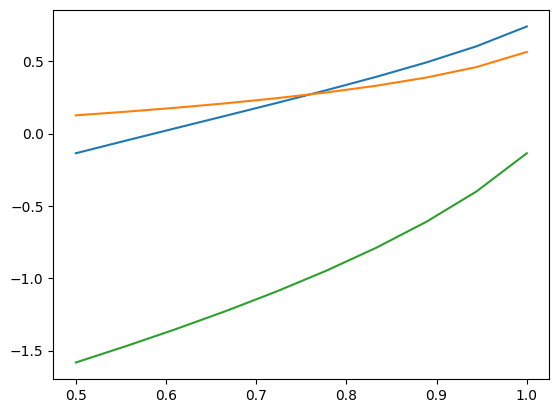

In [24]:
state_class = [ 'coherent']
det_modes = ['homodyne', 'heterodyne']
reconciliation_modes = ['direct', 'reverse']

from itertools import product

for states, det_mode, rec_mode in product(state_class, det_modes, reconciliation_modes):
    print(states, det_mode, rec_mode)
    plt.plot(T, mutual_information_CV(states, det_mode) - holevo_bound_CV(states, det_mode, rec_mode), label=f'{states}, {det_mode}, {rec_mode}')

plt.legend()
plt.grid()


# NOT WORKING YET --> SYMP EIGVALS LESS THAN 1